In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb

df = pd.read_csv("nasr_city_ml_dataset_with_predictions.csv")
df.head()

,area_id,center_lat,center_lon,cell_area_km2,main_road_name,notable_places,total_pois,competitor_supermarkets,competitor_convenience,restaurants_cafes,...,est_population_density,nearest_competitor_km,nearest_supermarket_km,nearest_warehouse_km,competitors_within_1km,suitability_score,road_importance_score,max_road_class,major_road_segments,predicted_score
0,grid_0_0,30.0165,31.3015,0.1109,شارع 17,ليالي كافيه,1,0,0,1,...,5131.0,0.886,0.886,4.180,1,59.83,0.898128,1.0,0.0,59.741350
1,grid_0_1,30.0165,31.3045,0.1109,شارع 17,NaN,0,0,0,0,...,4991.2,0.887,0.887,4.000,1,58.26,2.657506,5.0,0.0,58.206780
2,grid_0_2,30.0165,31.3075,0.1109,Unknown,NaN,0,0,0,0,...,6205.9,0.977,0.977,3.834,1,57.16,1.470989,1.0,0.0,57.188660
3,grid_0_3,30.0165,31.3105,0.1109,Unknown,NaN,0,0,0,0,...,6012.8,1.132,1.135,3.683,0,56.53,9.446515,5.0,0.0,56.648396
4,grid_0_4,30.0165,31.3135,0.1109,شارع 17,NaN,0,0,0,0,...,5523.8,1.017,1.338,3.549,0,59.39,1.505692,5.0,0.0,59.429120


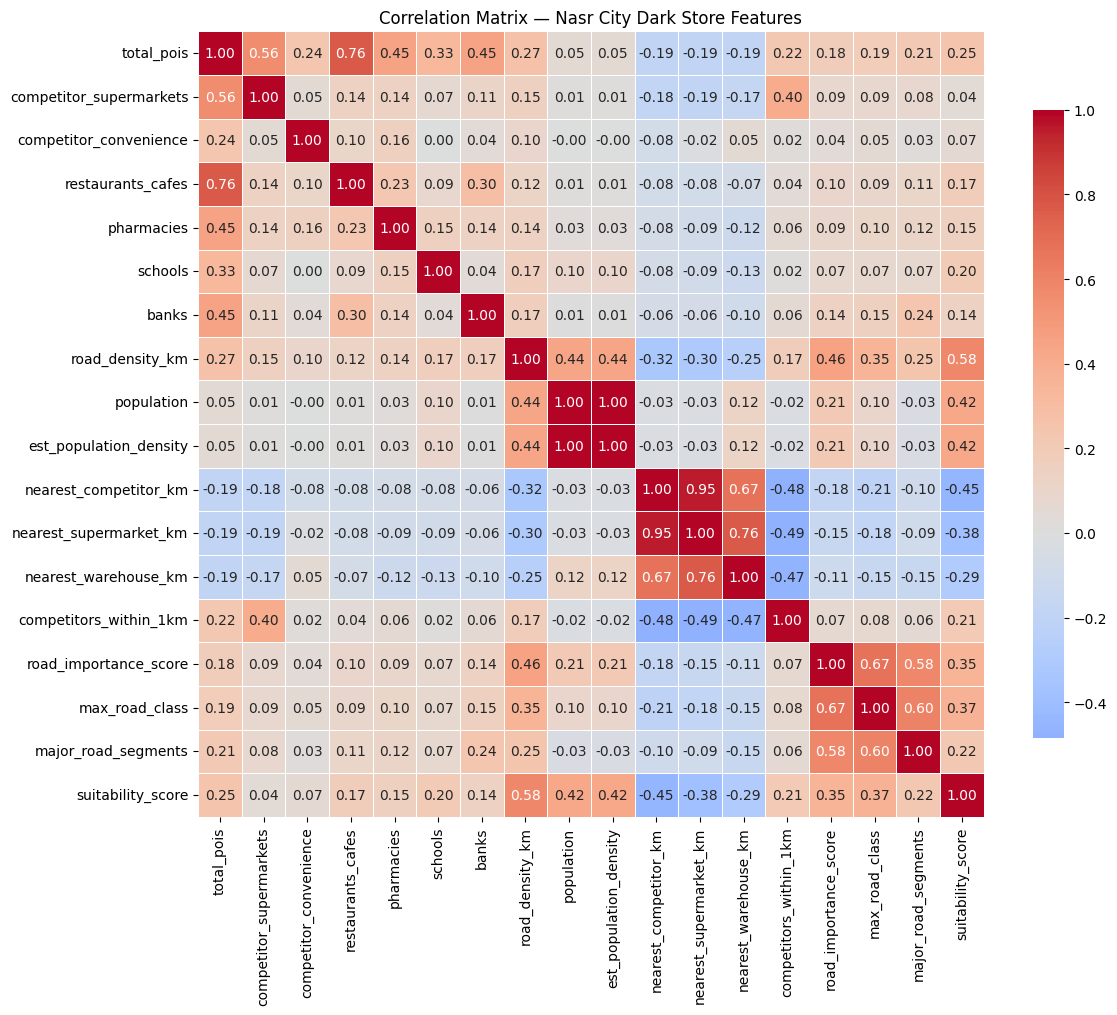

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Keep only features where a correlation actually means something:
# drop IDs, coordinates, and text columns
corr_cols = [
    "total_pois", "competitor_supermarkets", "competitor_convenience",
    "restaurants_cafes", "pharmacies", "schools", "banks",
    "road_density_km", "population", "est_population_density",
    "nearest_competitor_km", "nearest_supermarket_km", "nearest_warehouse_km",
    "competitors_within_1km", "road_importance_score", "max_road_class",
    "major_road_segments", "suitability_score",
]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix — Nasr City Dark Store Features")
plt.tight_layout()
plt.show()

Correlation with suitability_score (strongest first):
road_density_km            0.578699
nearest_competitor_km     -0.450830
population                 0.420654
est_population_density     0.420575
nearest_supermarket_km    -0.382985
max_road_class             0.371215
road_importance_score      0.351407
nearest_warehouse_km      -0.291796
total_pois                 0.253975
major_road_segments        0.218494
competitors_within_1km     0.210832
schools                    0.201722
restaurants_cafes          0.173668
pharmacies                 0.152733
banks                      0.140656
competitor_convenience     0.065612
competitor_supermarkets    0.043948
Name: suitability_score, dtype: float64


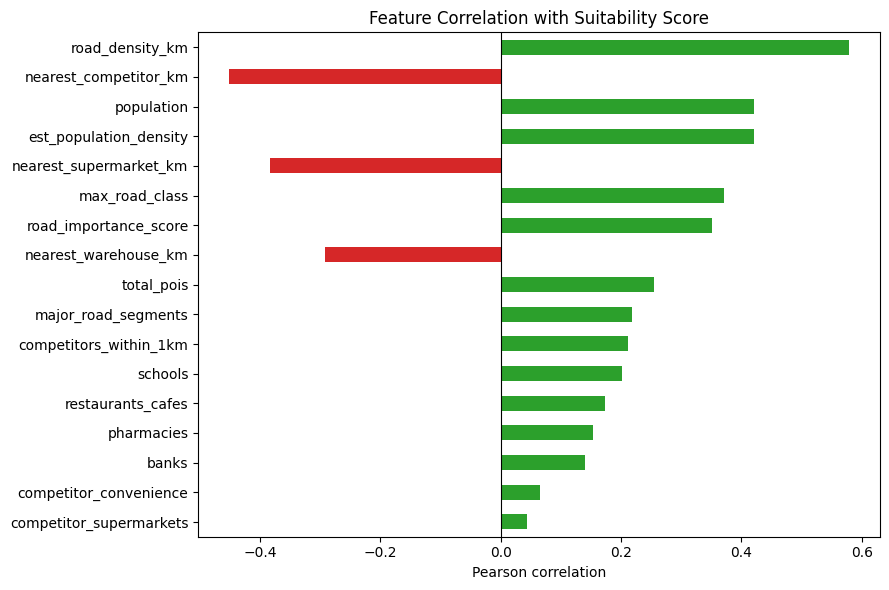

In [3]:
# Which features actually move together with the target (suitability_score)?
target_corr = corr_matrix["suitability_score"].drop("suitability_score").sort_values(key=abs, ascending=False)
print("Correlation with suitability_score (strongest first):")
print(target_corr)

plt.figure(figsize=(9, 6))
colors = target_corr.map(lambda v: "#d62728" if v < 0 else "#2ca02c")
target_corr.plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.gca().invert_yaxis()
plt.title("Feature Correlation with Suitability Score")
plt.xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

In [4]:
# Check for redundant features: pairs highly correlated with EACH OTHER
# (not the target) — these carry overlapping information
feature_corr = corr_matrix.drop(columns="suitability_score", index="suitability_score")
pairs = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool)).stack()
strong_pairs = pairs[pairs.abs() > 0.7].sort_values(key=abs, ascending=False)
print("Highly correlated feature pairs (|r| > 0.7):")
print(strong_pairs if len(strong_pairs) else "None found — features are reasonably independent, good for tree-based models.")

Highly correlated feature pairs (|r| > 0.7):
population              est_population_density    1.000000
nearest_competitor_km   nearest_supermarket_km    0.951460
total_pois              restaurants_cafes         0.764769
nearest_supermarket_km  nearest_warehouse_km      0.762944
dtype: float64


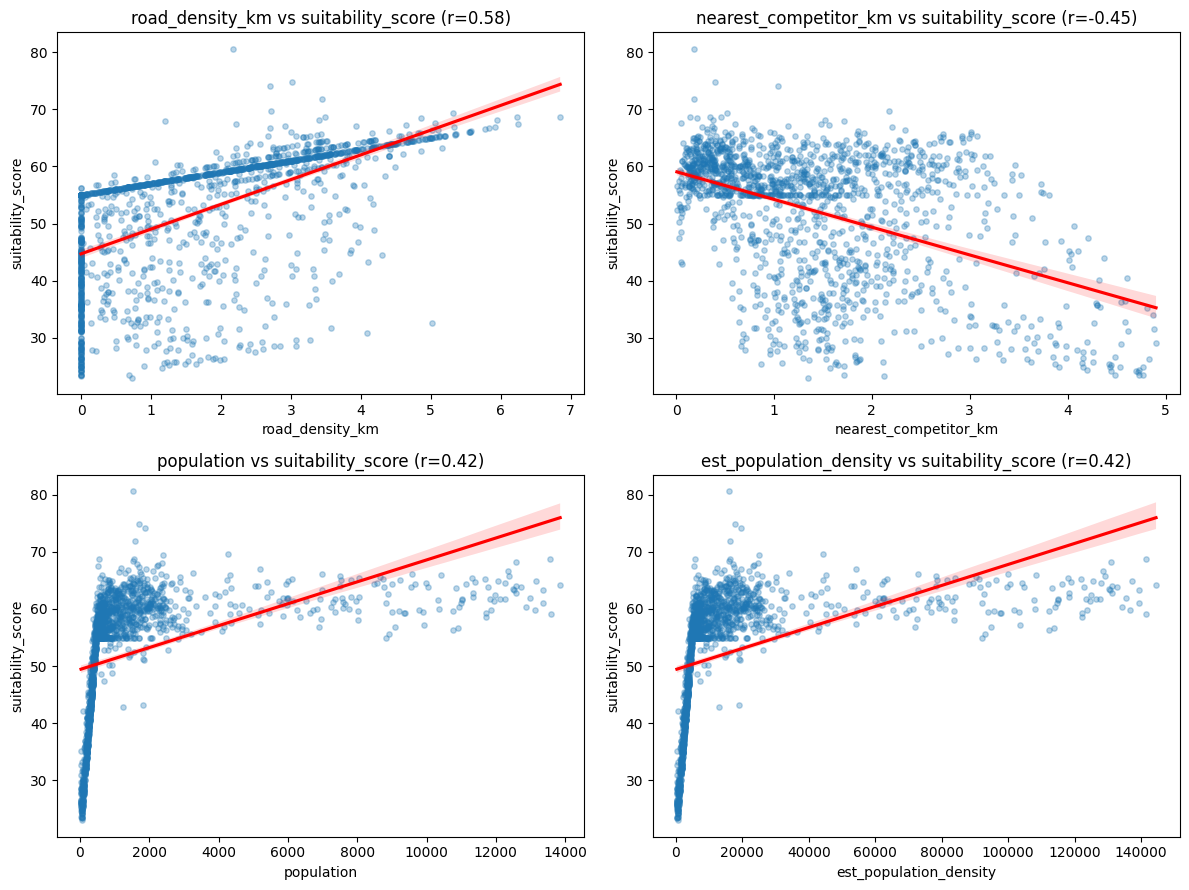

In [5]:
# Zoom in on the features most correlated with suitability_score
top_features = target_corr.abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, feat in zip(axes.flat, top_features):
    sns.regplot(data=df, x=feat, y="suitability_score", ax=ax,
                scatter_kws={"alpha": 0.3, "s": 15}, line_kws={"color": "red"})
    ax.set_title(f"{feat} vs suitability_score (r={corr_matrix.loc[feat, 'suitability_score']:.2f})")
plt.tight_layout()
plt.show()

In [6]:
# Features = everything numeric except the target and ID/text columns
drop_cols = ["area_id", "main_road_name", "notable_places", "suitability_score"]
X = df.drop(columns=drop_cols)
y = df["suitability_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
model = xgb.XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print("R2  :", round(r2_score(y_test, pred), 4))
print("MAE :", round(mean_absolute_error(y_test, pred), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred)), 3))

R2  : 0.9984
MAE : 0.131
RMSE: 0.438


In [8]:
# Retrain on all data, score every location, save results
model.fit(X, y)
df["predicted_score"] = model.predict(X)

best = df.sort_values("predicted_score", ascending=False).iloc[0]
print("Best location:")
print("Latitude :", best.center_lat)
print("Longitude:", best.center_lon)
print("Predicted score:", round(best.predicted_score, 2))

df.to_csv("nasr_city_ml_dataset_with_predictions.csv", index=False)
df.sort_values("predicted_score", ascending=False).head(10)[["area_id","center_lat","center_lon","predicted_score"]]

Best location:
Latitude : 30.0615
Longitude: 31.3465
Predicted score: 80.52


,area_id,center_lat,center_lon,predicted_score
615,grid_15_15,30.0615,31.3465,80.522461
616,grid_15_16,30.0615,31.3495,74.783897
1007,grid_25_7,30.0915,31.3225,74.110306
694,grid_17_14,30.0675,31.3435,71.853294
1082,grid_27_2,30.0975,31.3075,69.724472
612,grid_15_12,30.0615,31.3375,69.550255
656,grid_16_16,30.0645,31.3495,68.707008
708,grid_17_28,30.0675,31.3855,68.611343
1401,grid_35_1,30.1215,31.3045,68.604874
539,grid_13_19,30.0555,31.3585,68.462395


In [9]:
# Data validation
print(df.info())
print(df.isnull().sum())
print('Duplicates:', df.duplicated().sum())

# Cross validation
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print('CV R2 mean:', cv_scores.mean())

# Feature importance
import pandas as pd
fi = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(fi.head(15))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1560 entries, 0 to 1559
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   area_id                  1560 non-null   object 
 1   center_lat               1560 non-null   float64
 2   center_lon               1560 non-null   float64
 3   cell_area_km2            1560 non-null   float64
 4   main_road_name           1560 non-null   object 
 5   notable_places           361 non-null    object 
 6   total_pois               1560 non-null   int64  
 7   competitor_supermarkets  1560 non-null   int64  
 8   competitor_convenience   1560 non-null   int64  
 9   restaurants_cafes        1560 non-null   int64  
 10  pharmacies               1560 non-null   int64  
 11  schools                  1560 non-null   int64  
 12  banks                    1560 non-null   int64  
 13  road_density_km          1560 non-null   float64
 14  population              